In [1]:
import pandas as pd


In [233]:
stations = pd.read_csv('stations.csv')
city_day = pd.read_csv('city_day.csv')
city_hour = pd.read_csv('city_hour.csv')
station_day = pd.read_csv('station_day.csv')
station_hour = pd.read_csv('station_hour.csv',low_memory=False)

In [14]:
stations

,StationId,StationName,City,State,Status
0,AP001,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
1,AP002,"Anand Kala Kshetram, Rajamahendravaram - APPCB",Rajamahendravaram,Andhra Pradesh,NaN
2,AP003,"Tirumala, Tirupati - APPCB",Tirupati,Andhra Pradesh,NaN
3,AP004,"PWD Grounds, Vijayawada - APPCB",Vijayawada,Andhra Pradesh,NaN
4,AP005,"GVM Corporation, Visakhapatnam - APPCB",Visakhapatnam,Andhra Pradesh,Active
...,...,...,...,...,...
225,WB010,"Jadavpur, Kolkata - WBPCB",Kolkata,West Bengal,Active
226,WB011,"Rabindra Bharati University, Kolkata - WBPCB",Kolkata,West Bengal,Active
227,WB012,"Rabindra Sarobar, Kolkata - WBPCB",Kolkata,West Bengal,Active
228,WB013,"Victoria, Kolkata - WBPCB",Kolkata,West Bengal,Active


In [10]:
# Data of 2.5 Lakhs hourly data of 230 stations accross India

In [11]:
stations.columns

Index(['StationId', 'StationName', 'City', 'State', 'Status'], dtype='object')

In [16]:
stations[['City','State', 'Status']].describe()

,City,State,Status
count,230,230,133
unique,127,21,2
top,Delhi,Delhi,Active
freq,38,38,131


## Per Column count of missing values

In [25]:
station_day.isna().sum()

StationId         0
Date              0
PM2.5         21625
PM10          42706
NO            17106
NO2           16547
NOx           15500
NH3           48105
CO            12998
SO2           25204
O3            25568
Benzene       31455
Toluene       38702
Xylene        85137
AQI           21010
AQI_Bucket    21010
dtype: int64

In [27]:
station_day.isna().sum().sort_values(ascending=False)

Xylene        85137
NH3           48105
PM10          42706
Toluene       38702
Benzene       31455
O3            25568
SO2           25204
PM2.5         21625
AQI           21010
AQI_Bucket    21010
NO            17106
NO2           16547
NOx           15500
CO            12998
StationId         0
Date              0
dtype: int64

In [32]:
## Xylene has most missing values ie 78% data is missing

Missing values percentages


In [31]:
missing_percentage = station_day.isna().sum().sort_values(ascending=False)/len(station_day)
missing_percentage

Xylene        0.788050
NH3           0.445272
PM10          0.395298
Toluene       0.358236
Benzene       0.291156
O3            0.236664
SO2           0.233295
PM2.5         0.200167
AQI           0.194474
AQI_Bucket    0.194474
NO            0.158338
NO2           0.153163
NOx           0.143472
CO            0.120313
StationId     0.000000
Date          0.000000
dtype: float64

<Axes: >

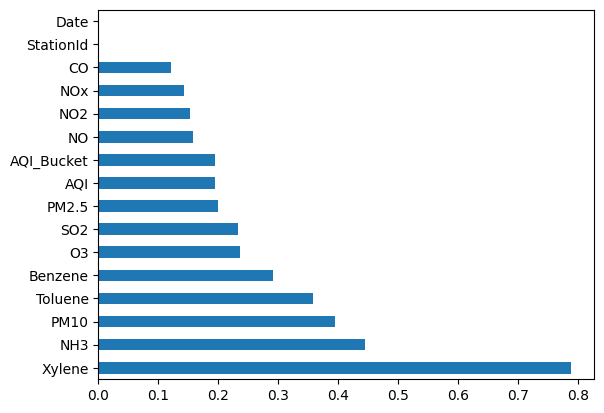

In [33]:
missing_percentage.plot(kind='barh')

In [47]:
city_day.City.unique() ##data of 26 cities

array(['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru',
       'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore',
       'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad',
       'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai',
       'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram',
       'Visakhapatnam'], dtype=object)

In [86]:
city_day = pd.read_csv('city_day.csv')

In [91]:
city_day[10230:12232]

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
10230,Delhi,2015-01-02,186.18,269.55,62.09,32.87,88.14,31.83,9.54,6.65,29.97,10.55,20.09,4.29,454.0,Severe
10231,Delhi,2015-01-03,87.18,131.90,25.73,30.31,47.95,69.55,10.61,2.65,19.71,3.91,10.23,1.99,143.0,Moderate
10232,Delhi,2015-01-04,151.84,241.84,25.01,36.91,48.62,130.36,11.54,4.63,25.36,4.26,9.71,3.34,319.0,Very Poor
10233,Delhi,2015-01-05,146.60,219.13,14.01,34.92,38.25,122.88,9.20,3.33,23.20,2.80,6.21,2.96,325.0,Very Poor
10234,Delhi,2015-01-06,149.58,252.10,17.21,37.84,42.46,134.97,9.44,3.66,26.83,3.63,7.35,3.47,318.0,Very Poor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12227,Delhi,2020-06-21,39.70,95.63,7.21,23.70,19.89,28.84,0.85,11.71,33.92,1.51,17.57,0.63,105.0,Moderate
12228,Delhi,2020-06-22,39.47,77.48,5.67,20.61,17.46,34.32,0.91,11.08,42.76,1.54,18.47,0.37,104.0,Moderate
12229,Delhi,2020-06-23,29.02,64.12,6.22,16.39,15.33,33.32,0.88,11.09,28.64,1.25,12.99,0.33,85.0,Satisfactory
12230,Delhi,2020-06-24,30.91,62.61,6.63,16.84,15.72,31.45,0.89,11.02,24.77,1.28,12.13,0.27,71.0,Satisfactory


In [96]:
delhi_df = city_day.loc[city_day['City'] == 'Delhi']

In [99]:
delhi_df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,2007.000000,1932.000000,2007.000000,2007.000000,2009.000000,2000.000000,2009.000000,1899.000000,1925.00000,2009.000000,2009.000000,1228.000000,1999.000000
mean,117.196153,232.809229,38.985595,50.785182,58.567023,41.997150,1.976053,15.901253,51.32361,3.544480,17.185042,1.438339,259.487744
std,82.912945,121.873025,33.389456,22.696721,37.690350,17.301221,2.560253,7.966770,26.06234,2.431232,15.291597,2.377762,119.537333
min,10.240000,18.590000,3.570000,10.630000,0.000000,6.780000,0.000000,2.340000,6.94000,0.000000,0.000000,0.000000,29.000000
25%,57.095000,137.040000,15.895000,33.895000,31.150000,31.157500,0.910000,10.335000,33.71000,1.870000,6.650000,0.110000,161.500000
50%,94.620000,216.730000,27.200000,47.150000,52.750000,38.040000,1.240000,14.450000,44.44000,2.960000,12.750000,0.650000,257.000000
75%,153.030000,311.667500,50.790000,63.570000,75.360000,48.792500,1.870000,19.700000,60.84000,4.680000,23.200000,1.970000,345.500000
max,685.360000,796.880000,221.030000,162.500000,254.800000,166.700000,30.440000,71.560000,257.73000,20.640000,103.000000,23.300000,716.000000


In [100]:
city_hour

,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01 01:00:00,NaN,NaN,1.00,40.01,36.37,NaN,1.00,122.07,NaN,0.0,0.0,0.0,NaN,NaN
1,Ahmedabad,2015-01-01 02:00:00,NaN,NaN,0.02,27.75,19.73,NaN,0.02,85.90,NaN,0.0,0.0,0.0,NaN,NaN
2,Ahmedabad,2015-01-01 03:00:00,NaN,NaN,0.08,19.32,11.08,NaN,0.08,52.83,NaN,0.0,0.0,0.0,NaN,NaN
3,Ahmedabad,2015-01-01 04:00:00,NaN,NaN,0.30,16.45,9.20,NaN,0.30,39.53,153.58,0.0,0.0,0.0,NaN,NaN
4,Ahmedabad,2015-01-01 05:00:00,NaN,NaN,0.12,14.90,7.85,NaN,0.12,32.63,NaN,0.0,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
707870,Visakhapatnam,2020-06-30 20:00:00,9.50,36.00,2.75,25.57,15.85,4.57,0.62,NaN,27.75,NaN,NaN,NaN,51.0,Satisfactory
707871,Visakhapatnam,2020-06-30 21:00:00,17.25,49.25,3.62,33.20,20.62,3.78,0.76,2.02,25.58,NaN,NaN,NaN,51.0,Satisfactory
707872,Visakhapatnam,2020-06-30 22:00:00,36.00,71.00,2.20,30.80,18.20,3.67,0.58,1.77,26.15,NaN,NaN,NaN,50.0,Good
707873,Visakhapatnam,2020-06-30 23:00:00,15.75,63.00,1.02,28.90,16.00,3.80,0.49,0.75,15.82,NaN,NaN,NaN,50.0,Good


In [101]:
delhi_hour_df = city_hour.loc[city_hour['City'] == 'Delhi']

In [114]:
type(delhi_hour_df.Datetime[245172])

str

In [115]:
pd.to_datetime(delhi_hour_df.Datetime)

245172   2015-01-01 01:00:00
245173   2015-01-01 02:00:00
245174   2015-01-01 03:00:00
245175   2015-01-01 04:00:00
245176   2015-01-01 05:00:00
                 ...        
293359   2020-06-30 20:00:00
293360   2020-06-30 21:00:00
293361   2020-06-30 22:00:00
293362   2020-06-30 23:00:00
293363   2020-07-01 00:00:00
Name: Datetime, Length: 48192, dtype: datetime64[ns]

### Hence string datetime converted to timestamp datatype

In [117]:
delhi_hour_df.loc['Datetime'] = pd.to_datetime(delhi_hour_df.Datetime)

C:\Users\Nikhil Arya\AppData\Local\Temp\ipykernel_544\37342640.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delhi_hour_df.loc['Datetime'] = pd.to_datetime(delhi_hour_df.Datetime)


In [118]:
delhi_hour_df

,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
245172,Delhi,2015-01-01 01:00:00,454.58,935.18,81.52,41.78,187.66,27.54,9.29,3.41,54.94,25.24,58.57,13.8,NaN,NaN
245173,Delhi,2015-01-01 02:00:00,440.44,NaN,70.8,43.46,176.83,27.72,13.28,3.88,50.53,23.1,49.37,15.63,NaN,NaN
245174,Delhi,2015-01-01 03:00:00,409.09,NaN,132.46,41.19,141.02,28.94,29.67,2.83,19.33,19.04,38.94,17.18,NaN,NaN
245175,Delhi,2015-01-01 04:00:00,436.12,NaN,84.78,39.55,102.84,29.3,21.76,4.33,20.08,13.99,27.53,16.82,NaN,NaN
245176,Delhi,2015-01-01 05:00:00,415.88,976.99,60.24,37.41,80.12,30.84,26.19,6.17,16.0,11.14,21.99,14.29,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
293360,Delhi,2020-06-30 21:00:00,45.3,125.22,6.34,22.91,17.96,29.95,1.04,10.59,39.62,1.72,18.06,1.16,99.0,Satisfactory
293361,Delhi,2020-06-30 22:00:00,49.04,129.39,6.29,20.95,16.8,30.01,1.0,10.2,38.95,1.66,16.17,1.18,101.0,Moderate
293362,Delhi,2020-06-30 23:00:00,50.51,128.86,6.19,20.4,16.83,29.4,0.94,10.98,34.53,1.6,16.79,0.85,102.0,Moderate
293363,Delhi,2020-07-01 00:00:00,54.01,128.66,6.33,21.05,16.81,29.06,0.97,11.15,29.73,2.03,23.57,0.65,101.0,Moderate


In [119]:
type(delhi_hour_df.Datetime[245172])

pandas._libs.tslibs.timestamps.Timestamp

In [123]:
time_df = delhi_hour_df.Datetime

In [127]:
import seaborn as sns

<Axes: xlabel='Datetime', ylabel='Count'>

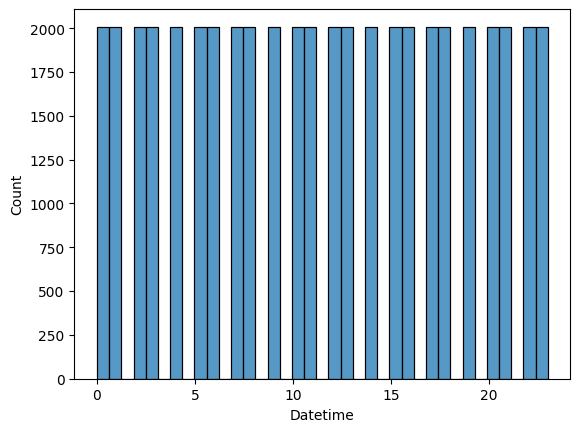

In [166]:
delhi_hour_df = city_hour.loc[city_hour['City'] == 'Delhi' and time_df.dt.year == 2015.0]

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [169]:
time_df[245172].year

2015

## Lets deep dive into 2015 year for Delhi's Air quality

In [180]:
delhi_hour_df[delhi_hour_df['Datetime'].dt.year == 2015.0]

,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
245172,Delhi,2015-01-01 01:00:00,454.58,935.18,81.52,41.78,187.66,27.54,9.29,3.41,54.94,25.24,58.57,13.8,NaN,NaN
245173,Delhi,2015-01-01 02:00:00,440.44,NaN,70.8,43.46,176.83,27.72,13.28,3.88,50.53,23.1,49.37,15.63,NaN,NaN
245174,Delhi,2015-01-01 03:00:00,409.09,NaN,132.46,41.19,141.02,28.94,29.67,2.83,19.33,19.04,38.94,17.18,NaN,NaN
245175,Delhi,2015-01-01 04:00:00,436.12,NaN,84.78,39.55,102.84,29.3,21.76,4.33,20.08,13.99,27.53,16.82,NaN,NaN
245176,Delhi,2015-01-01 05:00:00,415.88,976.99,60.24,37.41,80.12,30.84,26.19,6.17,16.0,11.14,21.99,14.29,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253926,Delhi,2015-12-31 19:00:00,142.61,359.15,75.98,93.07,171.46,61.63,2.64,19.93,48.9,3.49,11.11,0.0,412.0,Severe
253927,Delhi,2015-12-31 20:00:00,201.88,464.06,155.64,107.08,109.14,72.92,3.79,23.26,79.43,5.37,16.95,0.0,415.0,Severe
253928,Delhi,2015-12-31 21:00:00,272.73,535.32,154.26,107.86,170.23,78.44,2.89,22.78,133.28,7.53,29.56,0.0,432.0,Severe
253929,Delhi,2015-12-31 22:00:00,271.46,518.95,134.38,99.07,179.56,82.17,3.02,24.44,110.69,7.39,28.62,0.02,433.0,Severe


#### Only data of january

In [192]:
jan_2015_df = delhi_hour_df[(delhi_hour_df['Datetime'].dt.month == 1.0) & (delhi_hour_df['Datetime'].dt.year == 2015.0)]

In [193]:
jan_2015_df


,City,Datetime,PM2.5,PM10,NO,...,Benzene,Toluene,Xylene,AQI,AQI_Bucket
245172,Delhi,2015-01-01 01:00:00,454.58,935.18,81.52,...,25.24,58.57,13.8,NaN,NaN
245173,Delhi,2015-01-01 02:00:00,440.44,NaN,70.8,...,23.1,49.37,15.63,NaN,NaN
245174,Delhi,2015-01-01 03:00:00,409.09,NaN,132.46,...,19.04,38.94,17.18,NaN,NaN
245175,Delhi,2015-01-01 04:00:00,436.12,NaN,84.78,...,13.99,27.53,16.82,NaN,NaN
245176,Delhi,2015-01-01 05:00:00,415.88,976.99,60.24,...,11.14,21.99,14.29,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
245910,Delhi,2015-01-31 19:00:00,156.3,209.52,29.01,...,2.82,4.61,2.67,327.0,Very Poor
245911,Delhi,2015-01-31 20:00:00,190.8,309.52,67.05,...,7.4,15.01,3.15,328.0,Very Poor
245912,Delhi,2015-01-31 21:00:00,158.76,221.11,89.85,...,16.77,51.39,2.54,328.0,Very Poor
245913,Delhi,2015-01-31 22:00:00,183.39,298.09,114.32,...,10.01,21.85,3.17,328.0,Very Poor


In [189]:
delhi_hour_df['Datetime'].dt.day

245172       1.0
245173       1.0
245174       1.0
245175       1.0
245176       1.0
            ... 
293360      30.0
293361      30.0
293362      30.0
293363       1.0
Datetime     NaN
Name: Datetime, Length: 48193, dtype: float64

In [191]:
jan1_2015_df = delhi_hour_df[(delhi_hour_df['Datetime'].dt.month == 1.0) & (delhi_hour_df['Datetime'].dt.year == 2015.0) & (delhi_hour_df['Datetime'].dt.day == 1.0)]

## maximum pollution levels were in an around midnight with decreasing towards noon and increasing levels in late night

<Axes: ylabel='PM2.5'>

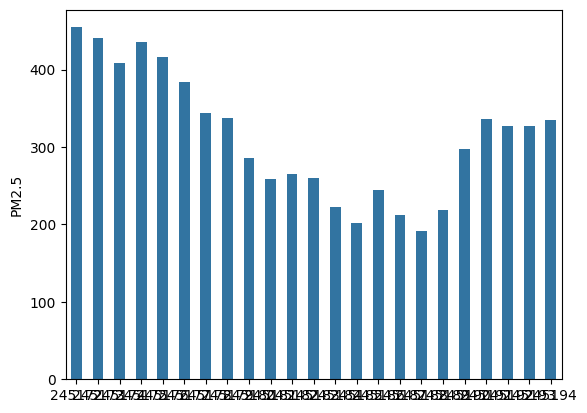

In [221]:
sns.barplot(jan1_2015_df['PM2.5'], width = 0.5)

In [223]:

jp_hour_df = city_hour.loc[city_hour['City'] == 'Jaipur']

In [224]:
jp_hour_df

,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
397583,Jaipur,2017-06-14 08:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
397584,Jaipur,2017-06-14 09:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
397585,Jaipur,2017-06-14 10:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
397586,Jaipur,2017-06-14 11:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
397587,Jaipur,2017-06-14 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
424283,Jaipur,2020-06-30 20:00:00,41.31,89.91,5.94,22.89,24.90,28.00,1.13,9.67,37.00,1.41,5.17,NaN,70.0,Satisfactory
424284,Jaipur,2020-06-30 21:00:00,42.20,96.70,8.88,27.46,31.91,34.85,1.17,8.60,27.94,2.71,6.72,NaN,71.0,Satisfactory
424285,Jaipur,2020-06-30 22:00:00,49.19,98.70,7.50,20.87,24.40,28.92,0.62,10.41,34.15,1.73,4.64,NaN,71.0,Satisfactory
424286,Jaipur,2020-06-30 23:00:00,44.36,90.35,5.25,14.35,17.02,20.65,0.49,7.29,50.81,0.57,1.54,NaN,70.0,Satisfactory


In [225]:
jp_time_df = jp_hour_df.Datetime

In [227]:
jp_hour_df.loc['Datetime'] = pd.to_datetime(jp_hour_df.Datetime)

C:\Users\Nikhil Arya\AppData\Local\Temp\ipykernel_544\2117492068.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  jp_hour_df.loc['Datetime'] = pd.to_datetime(jp_hour_df.Datetime)


In [228]:
jan1_2015_jp_df = jp_hour_df[(jp_hour_df['Datetime'].dt.month == 1.0) & (jp_hour_df['Datetime'].dt.year == 2015.0) & (jp_hour_df['Datetime'].dt.day == 1.0)]

AttributeError: Can only use .dt accessor with datetimelike values

In [229]:
jp_hour_df

,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
397583,Jaipur,2017-06-14 08:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
397584,Jaipur,2017-06-14 09:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
397585,Jaipur,2017-06-14 10:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
397586,Jaipur,2017-06-14 11:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
397587,Jaipur,2017-06-14 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
424284,Jaipur,2020-06-30 21:00:00,42.2,96.7,8.88,27.46,31.91,34.85,1.17,8.6,27.94,2.71,6.72,NaN,71.0,Satisfactory
424285,Jaipur,2020-06-30 22:00:00,49.19,98.7,7.5,20.87,24.4,28.92,0.62,10.41,34.15,1.73,4.64,NaN,71.0,Satisfactory
424286,Jaipur,2020-06-30 23:00:00,44.36,90.35,5.25,14.35,17.02,20.65,0.49,7.29,50.81,0.57,1.54,NaN,70.0,Satisfactory
424287,Jaipur,2020-07-01 00:00:00,58.79,103.68,5.19,10.88,14.16,17.41,0.54,5.19,53.68,0.22,0.46,NaN,70.0,Satisfactory


In [255]:
type(jp_hour_df.Datetime[397583])

str

In [258]:
jp_hour_df['Datetime'] = pd.to_datetime(jp_hour_df.Datetime)

C:\Users\Nikhil Arya\AppData\Local\Temp\ipykernel_544\3495335979.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  jp_hour_df['Datetime'] = pd.to_datetime(jp_hour_df.Datetime)


In [259]:
type(jp_hour_df.Datetime[397583])

pandas._libs.tslibs.timestamps.Timestamp

In [269]:
july1_2017_jp_df = jp_hour_df[(jp_hour_df['Datetime'].dt.month == 7.0) & (jp_hour_df['Datetime'].dt.year == 2017.0) & (jp_hour_df['Datetime'].dt.day == 1.0)]

## Jaipur month data of 1 July

In [270]:
july1_2017_jp_df

,City,Datetime,PM2.5,PM10,NO,...,Benzene,Toluene,Xylene,AQI,AQI_Bucket
397983,Jaipur,2017-07-01 00:00:00,26.12,50.4,4.59,...,0.0,0.12,NaN,46.0,Good
397984,Jaipur,2017-07-01 01:00:00,14.5,33.77,4.54,...,0.0,0.12,NaN,46.0,Good
397985,Jaipur,2017-07-01 02:00:00,9.3,19.63,4.73,...,0.0,0.0,NaN,46.0,Good
397986,Jaipur,2017-07-01 03:00:00,5.92,11.9,4.54,...,0.0,0.0,NaN,46.0,Good
397987,Jaipur,2017-07-01 04:00:00,4.52,8.5,4.4,...,0.0,0.0,NaN,46.0,Good
397988,Jaipur,2017-07-01 05:00:00,3.9,6.87,4.5,...,0.0,0.0,NaN,46.0,Good
397989,Jaipur,2017-07-01 06:00:00,5.5,5.63,4.66,...,0.0,0.0,NaN,46.0,Good
397990,Jaipur,2017-07-01 07:00:00,10.15,6.32,4.54,...,0.0,0.0,NaN,44.0,Good
397991,Jaipur,2017-07-01 08:00:00,16.5,6.65,4.57,...,0.0,0.0,NaN,44.0,Good
397992,Jaipur,2017-07-01 09:00:00,15.33,15.13,4.54,...,0.0,0.12,NaN,44.0,Good


<Axes: ylabel='PM2.5'>

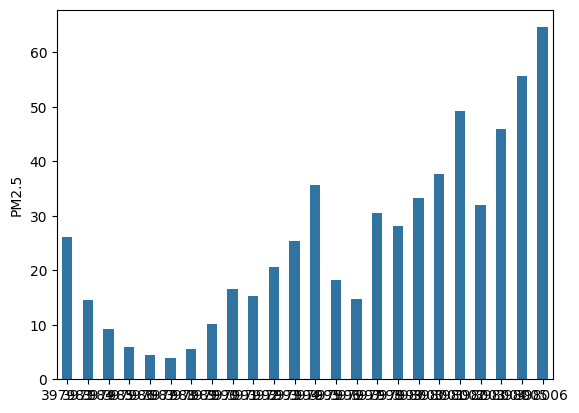

In [276]:
sns.barplot(july1_2017_jp_df['PM2.5'], width = 0.5, legend=True)


## Lets compare Delhi and Jaipur on 2019 November 1st

In [ ]:
## Jaipur 1 November data

In [277]:
nov_2020_jp_df = jp_hour_df[(jp_hour_df['Datetime'].dt.month == 11.0) & (jp_hour_df['Datetime'].dt.year == 2020.0) & (jp_hour_df['Datetime'].dt.day == 1.0)]

In [278]:
nov_2020_jp_df

,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket


In [286]:
nov1_2019_jp_df = jp_hour_df[(jp_hour_df['Datetime'].dt.month == 11.0) & (jp_hour_df['Datetime'].dt.year == 2019.0)& (jp_hour_df['Datetime'].dt.day == 1.0)]

In [287]:
nov1_2019_jp_df

,City,Datetime,PM2.5,PM10,NO,...,Benzene,Toluene,Xylene,AQI,AQI_Bucket
418455,Jaipur,2019-11-01 00:00:00,62.77,152.85,31.47,...,3.71,17.82,NaN,148.0,Moderate
418456,Jaipur,2019-11-01 01:00:00,49.23,128.12,27.01,...,3.14,16.08,NaN,148.0,Moderate
418457,Jaipur,2019-11-01 02:00:00,56.84,125.2,22.93,...,2.84,14.93,NaN,147.0,Moderate
418458,Jaipur,2019-11-01 03:00:00,55.59,114.94,20.19,...,2.65,13.52,NaN,147.0,Moderate
418459,Jaipur,2019-11-01 04:00:00,54.28,111.07,26.09,...,2.66,13.75,NaN,146.0,Moderate
418460,Jaipur,2019-11-01 05:00:00,39.85,89.02,27.17,...,2.64,14.1,NaN,144.0,Moderate
418461,Jaipur,2019-11-01 06:00:00,39.27,99.48,17.39,...,2.69,14.14,NaN,141.0,Moderate
418462,Jaipur,2019-11-01 07:00:00,40.69,105.11,20.58,...,3.01,13.57,NaN,139.0,Moderate
418463,Jaipur,2019-11-01 08:00:00,63.5,119.01,25.11,...,3.74,13.58,NaN,136.0,Moderate
418464,Jaipur,2019-11-01 09:00:00,54.9,139.42,10.42,...,3.61,13.18,NaN,131.0,Moderate


<Axes: ylabel='PM2.5'>

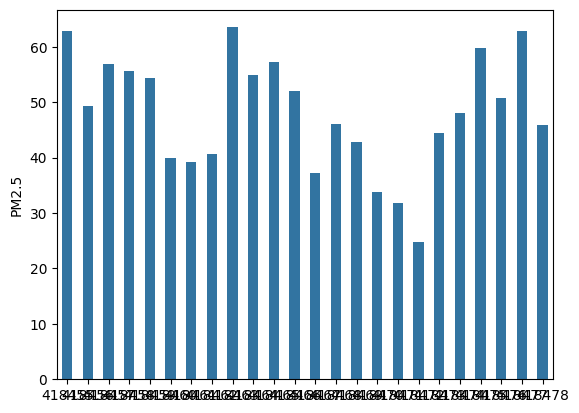

In [303]:
sns.barplot(nov1_2019_jp_df['PM2.5'], width = 0.5)

In [305]:
## Mean value of PM2.5

In [304]:
nov1_2019_jp_df['PM2.5'].sum()/len(nov1_2019_jp_df)

48.10166666666667

In [306]:
nov1_2019_df = delhi_hour_df[(delhi_hour_df['Datetime'].dt.month == 11.0) & (delhi_hour_df['Datetime'].dt.year == 2019.0) & (delhi_hour_df['Datetime'].dt.day == 1.0)]

<Axes: ylabel='PM2.5'>

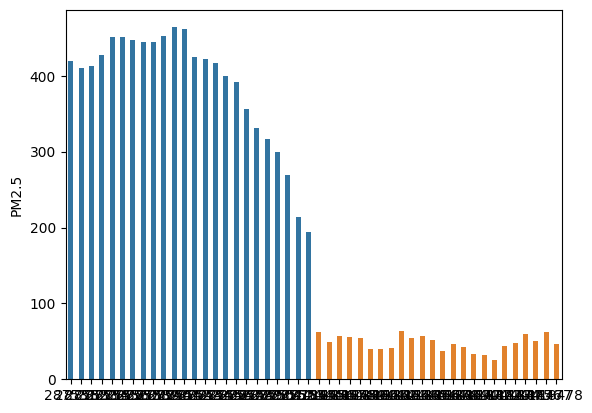

In [313]:
sns.barplot(nov1_2019_df['PM2.5'], width = 0.5)
sns.barplot(nov1_2019_jp_df['PM2.5'], width = 0.5)

## Summary / Insights


* Pollution levels in delhi durning the month of 1 november 2019 are very poor to severe category where as in jaipur are in satisfactory category

* most of jaipur data is missing